In [1]:
import sqlite3
from src.utils import sql_to_df, selecc_features,train_test_split_selector,model_baseline_train,model_baseline_evaluate,calcular_ndcg_por_usuario,calcular_feature_importance
from src.config import BASE_DB
import pandas as pd

ImportError: cannot import name 'sql_to_df' from 'src.utils' (c:\Users\chris\Data_science\Ms Data Mining UBA\2do año\2do Cuatrimestre\Sistemas Recomendacion\Proyecto\book-recommendation-system\book-recommendation-system\src\utils.py)

Cargando historia de usuarios...
Cargando resultados de los checkpoints...


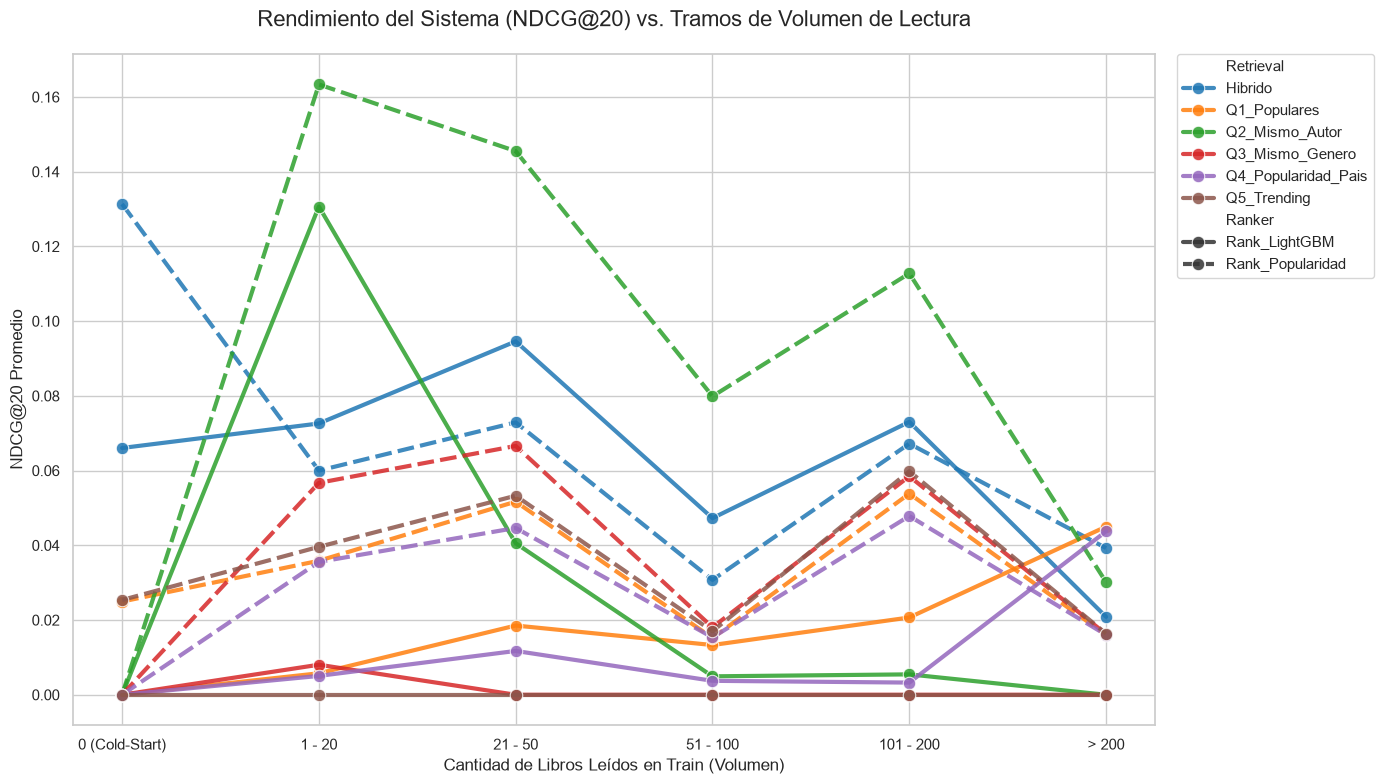

In [6]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# 1. CARGAR DATOS Y SEPARAR DIMENSIONES
# =============================================================================
print("Cargando historia de usuarios...")
df_train_feat = pd.read_csv("outputs/datasets/df_train_features.csv", usecols=["id_lector", "volumen_lectura_por_lector"])
df_volumen = df_train_feat.drop_duplicates(subset=["id_lector"])

print("Cargando resultados de los checkpoints...")
archivos_ckpt = glob.glob("outputs/checkpoints/ckpt_*.csv")

lista_resultados = []
for archivo in archivos_ckpt:
    nombre_base = os.path.basename(archivo).replace("ckpt_", "").replace(".csv", "")
    
    if "_Rank_" in nombre_base:
        nombre_ret, nombre_rank = nombre_base.split("_Rank_")
        nombre_rank = "Rank_" + nombre_rank
    else:
        nombre_ret = nombre_base
        nombre_rank = "Desconocido"
    
    df_ckpt = pd.read_csv(archivo, usecols=["id_lector", "ndcg"])
    df_ckpt["Retrieval"] = nombre_ret
    df_ckpt["Ranker"] = nombre_rank
    
    lista_resultados.append(df_ckpt)

df_todos = pd.concat(lista_resultados, ignore_index=True)

# =============================================================================
# 2. MERGE Y BINES DE VOLUMEN (CON GRUPO 0 AISLADO)
# =============================================================================
df_analisis = pd.merge(df_todos, df_volumen, on="id_lector", how="left")

# Llenamos con 0 a los usuarios de test que no estaban en train (Pure Cold-Start)
df_analisis['volumen_lectura_por_lector'] = df_analisis['volumen_lectura_por_lector'].fillna(0)

# MAGIA ACÁ: Intervalo (-1, 0] atrapa solo al 0.
cortes = [-1, 0, 20, 50, 100, 200, float('inf')]
etiquetas = ['0 (Cold-Start)', '1 - 20', '21 - 50', '51 - 100', '101 - 200', '> 200']

df_analisis['Rango_Volumen'] = pd.cut(df_analisis['volumen_lectura_por_lector'], bins=cortes, labels=etiquetas)

# =============================================================================
# 3. AGRUPAMIENTO
# =============================================================================
df_agrupado_rangos = df_analisis.groupby(["Retrieval", "Ranker", "Rango_Volumen"], observed=True)["ndcg"].mean().reset_index()

# =============================================================================
# 4. GRAFICACIÓN CON ALTO CONTRASTE Y ESTILOS
# =============================================================================
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 8))

sns.lineplot(
    data=df_agrupado_rangos, 
    x="Rango_Volumen", 
    y="ndcg", 
    hue="Retrieval",
    style="Ranker",
    palette="tab10",
    linewidth=3,
    marker="o",
    markersize=9,
    alpha=0.85
)

plt.title("Rendimiento del Sistema (NDCG@20) vs. Tramos de Volumen de Lectura", fontsize=16, pad=20)
plt.xlabel("Cantidad de Libros Leídos en Train (Volumen)", fontsize=12)
plt.ylabel("NDCG@20 Promedio", fontsize=12)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

Cargando historia de usuarios...
Cargando resultados de los checkpoints...


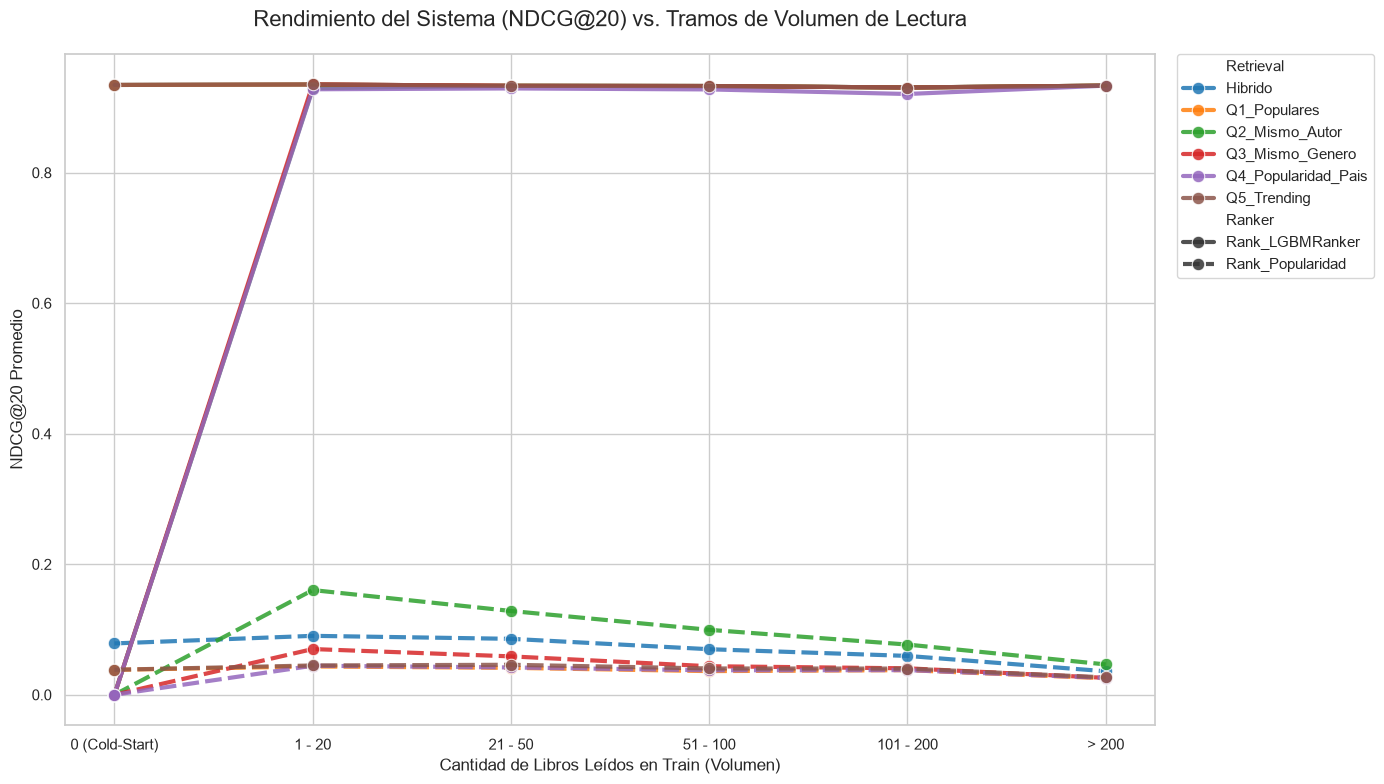

In [8]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# 1. CARGAR DATOS Y SEPARAR DIMENSIONES
# =============================================================================
print("Cargando historia de usuarios...")
df_train_feat = pd.read_csv("outputs/datasets/df_train_features.csv", usecols=["id_lector", "volumen_lectura_por_lector"])
df_volumen = df_train_feat.drop_duplicates(subset=["id_lector"])

print("Cargando resultados de los checkpoints...")
archivos_ckpt = glob.glob("outputs/checkpoints/ckpt_*.csv")

lista_resultados = []
for archivo in archivos_ckpt:
    nombre_base = os.path.basename(archivo).replace("ckpt_", "").replace(".csv", "")
    
    if "_Rank_" in nombre_base:
        nombre_ret, nombre_rank = nombre_base.split("_Rank_")
        nombre_rank = "Rank_" + nombre_rank
    else:
        nombre_ret = nombre_base
        nombre_rank = "Desconocido"
    
    df_ckpt = pd.read_csv(archivo, usecols=["id_lector", "ndcg"])
    df_ckpt["Retrieval"] = nombre_ret
    df_ckpt["Ranker"] = nombre_rank
    
    lista_resultados.append(df_ckpt)

df_todos = pd.concat(lista_resultados, ignore_index=True)

# =============================================================================
# 2. MERGE Y BINES DE VOLUMEN (CON GRUPO 0 AISLADO)
# =============================================================================
df_analisis = pd.merge(df_todos, df_volumen, on="id_lector", how="left")

# Llenamos con 0 a los usuarios de test que no estaban en train (Pure Cold-Start)
df_analisis['volumen_lectura_por_lector'] = df_analisis['volumen_lectura_por_lector'].fillna(0)

# MAGIA ACÁ: Intervalo (-1, 0] atrapa solo al 0.
cortes = [-1, 0, 20, 50, 100, 200, float('inf')]
etiquetas = ['0 (Cold-Start)', '1 - 20', '21 - 50', '51 - 100', '101 - 200', '> 200']

df_analisis['Rango_Volumen'] = pd.cut(df_analisis['volumen_lectura_por_lector'], bins=cortes, labels=etiquetas)

# =============================================================================
# 3. AGRUPAMIENTO
# =============================================================================
df_agrupado_rangos = df_analisis.groupby(["Retrieval", "Ranker", "Rango_Volumen"], observed=True)["ndcg"].mean().reset_index()

# =============================================================================
# 4. GRAFICACIÓN CON ALTO CONTRASTE Y ESTILOS
# =============================================================================
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 8))

sns.lineplot(
    data=df_agrupado_rangos, 
    x="Rango_Volumen", 
    y="ndcg", 
    hue="Retrieval",
    style="Ranker",
    palette="tab10",
    linewidth=3,
    marker="o",
    markersize=9,
    alpha=0.85
)

plt.title("Rendimiento del Sistema (NDCG@20) vs. Tramos de Volumen de Lectura", fontsize=16, pad=20)
plt.xlabel("Cantidad de Libros Leídos en Train (Volumen)", fontsize=12)
plt.ylabel("NDCG@20 Promedio", fontsize=12)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

In [ ]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# 1. CARGAR DATOS Y SEPARAR DIMENSIONES
# =============================================================================
print("Cargando historia de usuarios...")
df_train_feat = pd.read_csv("outputs/datasets/df_train_features.csv", usecols=["id_lector", "volumen_lectura_por_lector"])
df_volumen = df_train_feat.drop_duplicates(subset=["id_lector"])

print("Cargando resultados de los checkpoints...")
archivos_ckpt = glob.glob("outputs/checkpoints/ckpt_*.csv")

lista_resultados = []
for archivo in archivos_ckpt:
    nombre_base = os.path.basename(archivo).replace("ckpt_", "").replace(".csv", "")
    
    if "_Rank_" in nombre_base:
        nombre_ret, nombre_rank = nombre_base.split("_Rank_")
        nombre_rank = "Rank_" + nombre_rank
    else:
        nombre_ret = nombre_base
        nombre_rank = "Desconocido"
    
    df_ckpt = pd.read_csv(archivo, usecols=["id_lector", "ndcg"])
    df_ckpt["Retrieval"] = nombre_ret
    df_ckpt["Ranker"] = nombre_rank
    
    lista_resultados.append(df_ckpt)

df_todos = pd.concat(lista_resultados, ignore_index=True)

# =============================================================================
# 2. MERGE Y BINES DE VOLUMEN (CON GRUPO 0 AISLADO)
# =============================================================================
df_analisis = pd.merge(df_todos, df_volumen, on="id_lector", how="left")

# Llenamos con 0 a los usuarios de test que no estaban en train (Pure Cold-Start)
df_analisis['volumen_lectura_por_lector'] = df_analisis['volumen_lectura_por_lector'].fillna(0)

# MAGIA ACÁ: Intervalo (-1, 0] atrapa solo al 0.
cortes = [-1, 0, 20, 50, 100, 200, float('inf')]
etiquetas = ['0 (Cold-Start)', '1 - 20', '21 - 50', '51 - 100', '101 - 200', '> 200']

df_analisis['Rango_Volumen'] = pd.cut(df_analisis['volumen_lectura_por_lector'], bins=cortes, labels=etiquetas)

# =============================================================================
# 3. AGRUPAMIENTO
# =============================================================================
df_agrupado_rangos = df_analisis.groupby(["Retrieval", "Ranker", "Rango_Volumen"], observed=True)["ndcg"].mean().reset_index()

# =============================================================================
# 4. GRAFICACIÓN CON ALTO CONTRASTE Y ESTILOS
# =============================================================================
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 8))

sns.lineplot(
    data=df_agrupado_rangos, 
    x="Rango_Volumen", 
    y="ndcg", 
    hue="Retrieval",
    style="Ranker",
    palette="tab10",
    linewidth=3,
    marker="o",
    markersize=9,
    alpha=0.85
)

plt.title("Rendimiento del Sistema (NDCG@20) vs. Tramos de Volumen de Lectura", fontsize=16, pad=20)
plt.xlabel("Cantidad de Libros Leídos en Train (Volumen)", fontsize=12)
plt.ylabel("NDCG@20 Promedio", fontsize=12)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()